### #6

Kaggle competition: [\[link\]](https://www.kaggle.com/competitions/playground-series-s5e6)

Entry by Robin R.P.M. Kras

In [1]:
# General
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Machine Learning
import xgboost as xg

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error, roc_auc_score
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

from imblearn.over_sampling import SMOTE

# Feature Importance & Explainability
import shap

# Settings
import warnings
warnings.filterwarnings("ignore")

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

print("Libraries loaded. Ready to go!")

Libraries loaded. Ready to go!


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.head()

,id,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,0,37,70,36,Clayey,Sugarcane,36,4,5,28-28
1,1,27,69,65,Sandy,Millets,30,6,18,28-28
2,2,29,63,32,Sandy,Millets,24,12,16,17-17-17
3,3,35,62,54,Sandy,Barley,39,12,4,10-26-26
4,4,35,58,43,Red,Paddy,37,2,16,DAP


In [3]:
test.head()

,id,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous
0,750000,31,70,52,Sandy,Wheat,34,11,24
1,750001,27,62,45,Red,Sugarcane,30,14,15
2,750002,28,72,28,Clayey,Ground Nuts,14,15,4
3,750003,37,53,57,Black,Ground Nuts,18,17,36
4,750004,31,55,32,Red,Pulses,13,19,14


In [4]:
fertilizers = train['Fertilizer Name'].unique()
for i in fertilizers:
    print(i)

28-28
17-17-17
10-26-26
DAP
20-20
14-35-14
Urea


In [5]:
mapping_dict = {
    '28-28'     : 0, 
    '17-17-17'  : 1, 
    '10-26-26'  : 2, 
    'DAP'       : 3,
    '20-20'     : 4,
    '14-35-14'  : 5,
    'Urea'      : 6
}

train['Fertilizer Name'] = train['Fertilizer Name'].map(mapping_dict, na_action='ignore')

In [6]:
fertilizers = train['Fertilizer Name'].unique()
for i in fertilizers:
    print(i)

0
1
2
3
4
5
6


## train exploration

In [7]:
def plot_nums(trainframe):
    float_cols = [col for col in trainframe.columns if trainframe[col].dtype == "float64" or trainframe[col].dtype == "int64"]

    cols_per_row = 3
    num_plots = len(float_cols)
    rows = (num_plots // cols_per_row) + (num_plots % cols_per_row > 0) 

    fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 5 * rows)) 
    axes = axes.flatten()  

    for idx, col in enumerate(float_cols):
        sns.histplot(trainframe[col], bins=50, kde=True, ax=axes[idx])
        axes[idx].set_title(f"Distribution of {col}")

    for i in range(idx + 1, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

In [8]:
def plot_cats(trainframe):
    categorical_features = trainframe.select_dtypes(include=['object']).columns

    num_features = len(categorical_features)
    cols = 3 
    rows = (num_features // cols) + (num_features % cols > 0) 

    # Create subplots
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5)) 
    axes = axes.flatten()  

    for i, feature in enumerate(categorical_features):
        trainframe[feature].value_counts().plot.pie(
            autopct='%1.1f%%', ax=axes[i], startangle=90, cmap="viridis"
        )
        axes[i].set_title(feature)
        axes[i].set_ylabel("") 

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [9]:
train.dtypes

id                  int64
Temparature         int64
Humidity            int64
Moisture            int64
Soil Type          object
Crop Type          object
Nitrogen            int64
Potassium           int64
Phosphorous         int64
Fertilizer Name     int64
dtype: object

In [10]:
nums, cats = [], []

for col in train.columns:
    if train[col].dtype == 'int64':
        nums.append(col)
    elif train[col].dtype == 'object':
        cats.append(col)

In [11]:
print(nums)
print(cats)

['id', 'Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name']
['Soil Type', 'Crop Type']


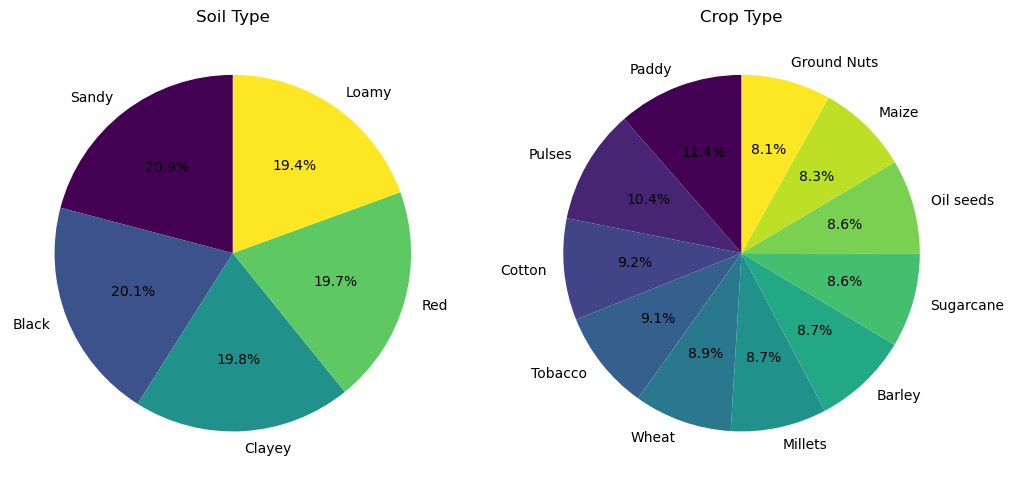

In [12]:
plot_cats(train)

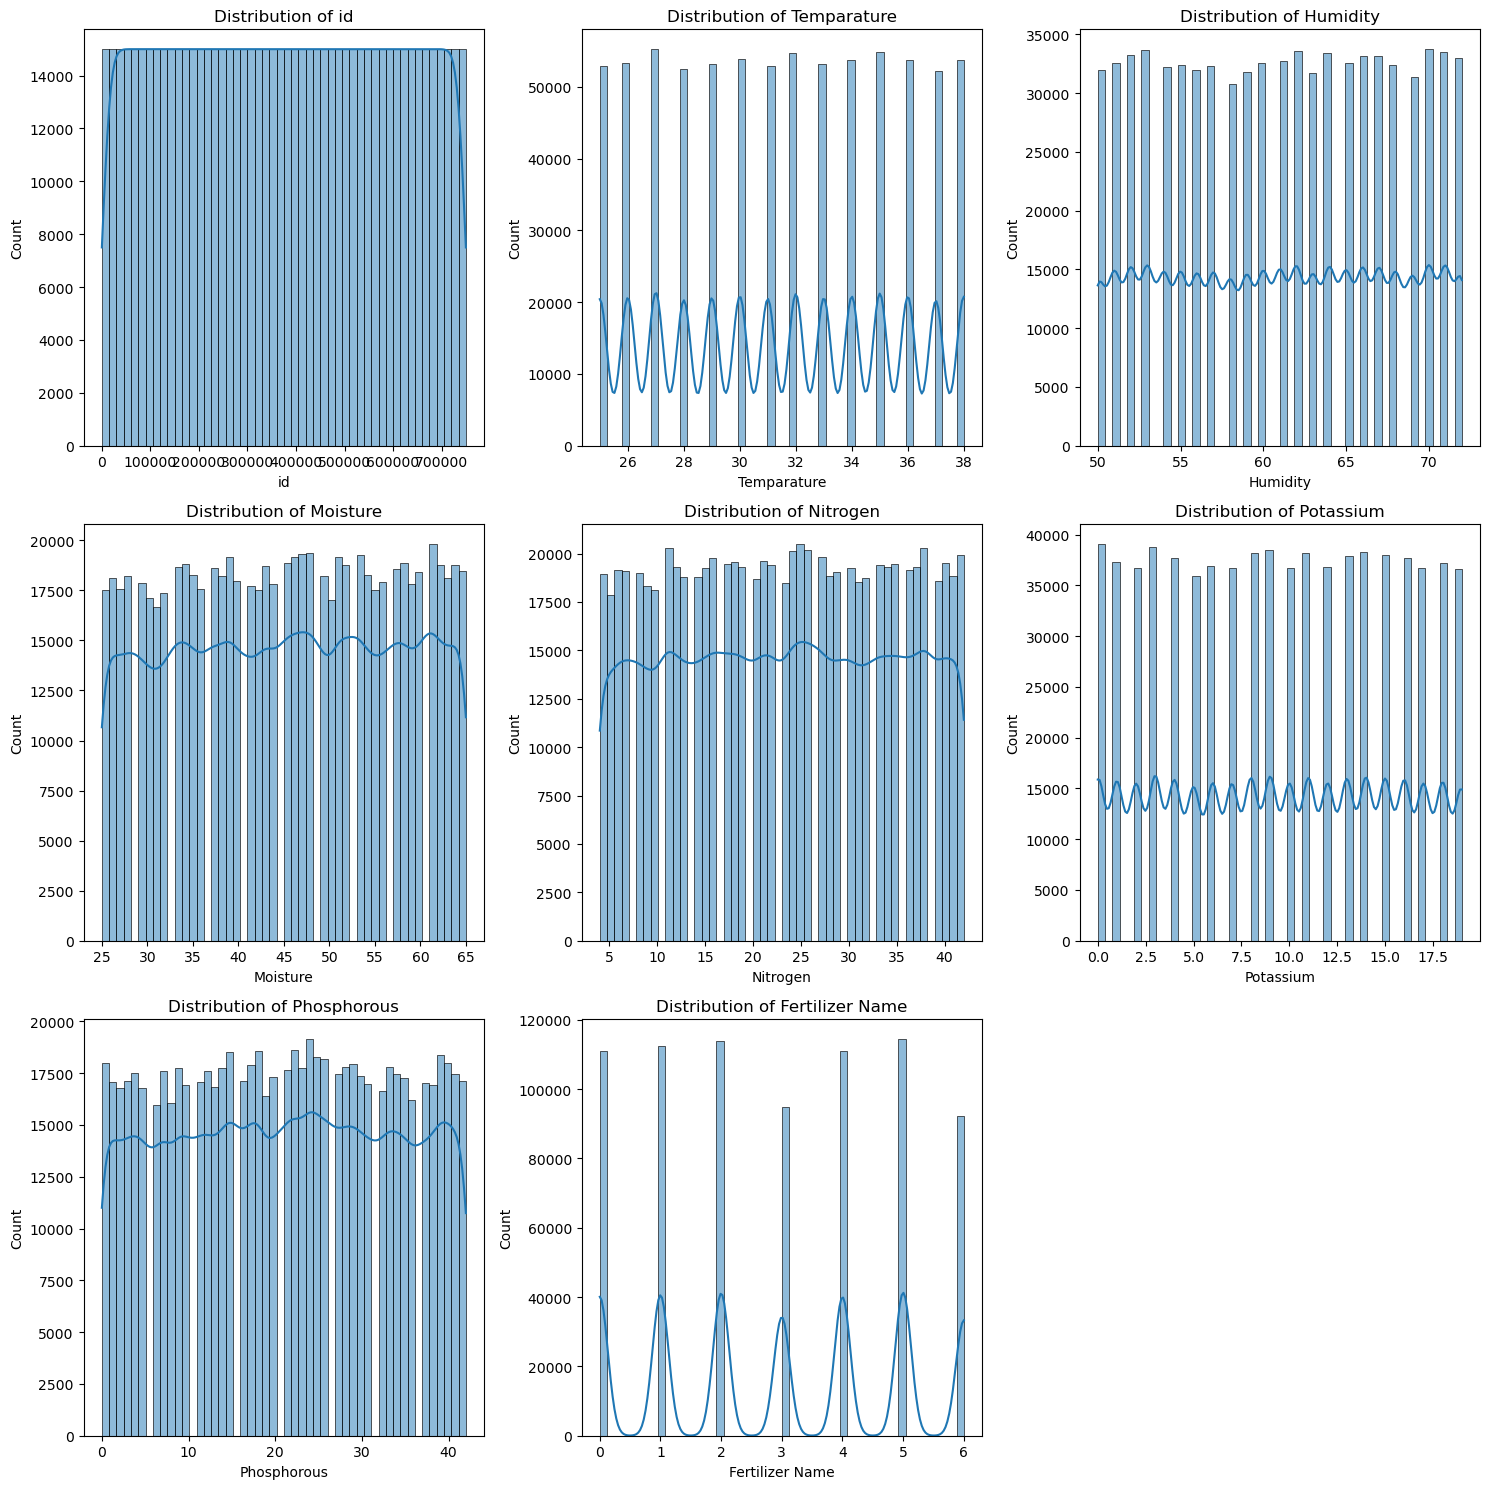

In [13]:
plot_nums(train)

Probably fine to just move ahead, shall we? Most distributions are somewhat equal

In [14]:
from sklearn.metrics import average_precision_score

In [15]:
def mapk(actual, predicted, k=3):
    """
    Computes the mean average precision at k.

    Parameters:
    - actual: list of true labels (e.g., ['cat'])
    - predicted: list of lists of predicted labels (e.g., [['cat', 'dog', 'rabbit']])
    - k: cutoff rank (e.g., 3 for MAP@3)

    Returns:
    - score: mean average precision at k
    """
    def apk(a, p, k):
        if len(p) > k:
            p = p[:k]
        score = 0.0
        num_hits = 0.0
        for i, pred in enumerate(p):
            if pred == a and pred not in p[:i]:
                num_hits += 1.0
                score += num_hits / (i + 1.0)
        return score

    return sum(apk(a, p, k) for a, p in zip(actual, predicted)) / len(actual)

In [16]:
train.dtypes

id                  int64
Temparature         int64
Humidity            int64
Moisture            int64
Soil Type          object
Crop Type          object
Nitrogen            int64
Potassium           int64
Phosphorous         int64
Fertilizer Name     int64
dtype: object

In [17]:
train['Soil Type'].unique()

array(['Clayey', 'Sandy', 'Red', 'Loamy', 'Black'], dtype=object)

In [18]:
train['Crop Type'].unique()

array(['Sugarcane', 'Millets', 'Barley', 'Paddy', 'Pulses', 'Tobacco',
       'Ground Nuts', 'Maize', 'Cotton', 'Wheat', 'Oil seeds'],
      dtype=object)

In [38]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler as sc

encoders = {}
for col in ['Soil Type', 'Crop Type']:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])
    encoders[col] = le

In [39]:
X = train.drop(columns=['Fertilizer Name'], errors='ignore')
y = train['Fertilizer Name']

In [40]:
train.head()

,id,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,0,37,70,36,1,8,36,4,5,0
1,1,27,69,65,4,4,30,6,18,0
2,2,29,63,32,4,4,24,12,16,1
3,3,35,62,54,4,0,39,12,4,2
4,4,35,58,43,3,6,37,2,16,3


In [41]:
train.dtypes

id                 int64
Temparature        int64
Humidity           int64
Moisture           int64
Soil Type          int64
Crop Type          int64
Nitrogen           int64
Potassium          int64
Phosphorous        int64
Fertilizer Name    int64
dtype: object

--

In [42]:
X = train.drop(columns=['Fertilizer Name'], errors='ignore')
X_test = test

y = train['Fertilizer Name']

In [43]:
X_test.dtypes

id             int64
Temparature    int64
Humidity       int64
Moisture       int64
Soil Type      int64
Crop Type      int64
Nitrogen       int64
Potassium      int64
Phosphorous    int64
dtype: object

In [44]:
params = {'booster': 'gbtree', 'lambda': 0.0020783289240041665, 'alpha': 2.2168644728594176, 'colsample_bytree': 0.44422864696491604, 'subsample': 0.9475504491795927, 'learning_rate': 0.28421823464256063, 'max_depth': 10, 'min_child_weight': 5}

In [45]:
model = xg.XGBClassifier(**params)
model.fit(X, y)

proba = model.predict_proba(X_test)

top3_indices = np.argsort(proba, axis=1)[:, ::-1][:, :3]

mapping_dict = {
    0: '28-28', 
    1: '17-17-17', 
    2: '10-26-26', 
    3: 'DAP',
    4: '20-20',
    5: '14-35-14',
    6: 'Urea'      
}

top3_fertilizers = []
for preds in top3_indices:
    names = [mapping_dict.get(i, 'Unknown') for i in preds]
    top3_fertilizers.append(' '.join(names))

output = pd.DataFrame({
    'id': test.id,
    'Fertilizer Name': top3_fertilizers
})

output.to_csv('s1.csv', index=False)
print("Your submission with concatenated top 3 predictions was successfully saved!")

Your submission with concatenated top 3 predictions was successfully saved!


In [46]:
output.head()

,id,Fertilizer Name
0,750000,20-20 28-28 10-26-26
1,750001,17-17-17 Urea 20-20
2,750002,20-20 10-26-26 28-28
3,750003,14-35-14 17-17-17 Urea
4,750004,28-28 20-20 10-26-26
